Training samples: 80000, Features: 20

Optimizer                        Time (s)   Param Updates      Train Loss       Test Loss
------------------------------------------------------------------------------------------
Standard (Full-Batch) GD           0.0457              20         0.00810         0.00819
Mini-Batch GD (bs=64)              0.6755           25000         0.00823         0.00831
Stochastic GD (SGD)               11.7617         1600000         0.00898         0.00905


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/gd_comparison.png'

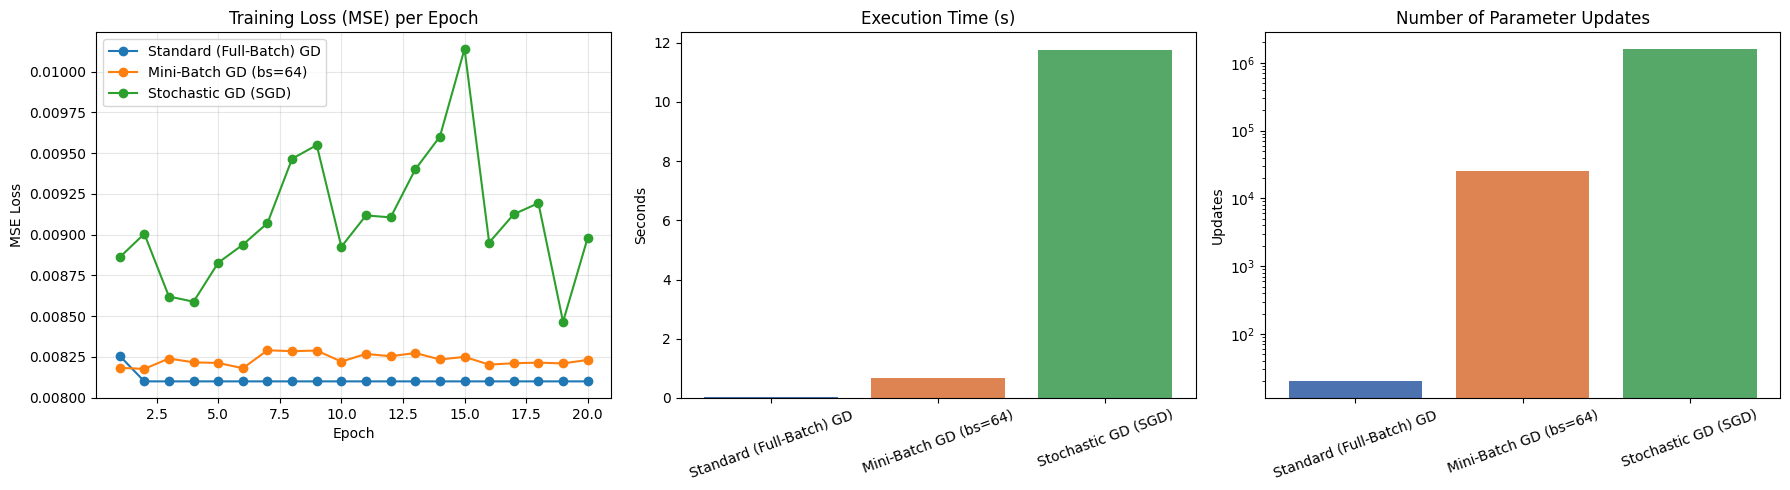

In [ ]:


import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------------------
# 1. Create a reasonably large synthetic regression dataset
# ----------------------------------------------------------------------
N_SAMPLES = 100_000
N_FEATURES = 20

X, y = make_regression(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    noise=15.0,
    random_state=42,
)

# Standardize features (important for gradient descent convergence)
X = StandardScaler().fit_transform(X)
y = (y - y.mean()) / y.std()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n, d = X_train.shape
print(f"Training samples: {n}, Features: {d}")

# ----------------------------------------------------------------------
# 2. Linear Regression via Gradient Descent (generic implementation)
# ----------------------------------------------------------------------
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])


def mse_loss(X, y, w):
    preds = X @ w
    return np.mean((preds - y) ** 2)


def gradient(X_batch, y_batch, w):
    m = X_batch.shape[0]
    preds = X_batch @ w
    grad = (2.0 / m) * (X_batch.T @ (preds - y_batch))
    return grad


def run_gradient_descent(X, y, mode="batch", batch_size=64,
                          epochs=20, lr=0.05, seed=0):
    """
    mode: 'batch'      -> standard/full-batch GD (1 update per epoch)
          'mini_batch'  -> mini-batch GD (batch_size samples per update)
          'stochastic'  -> SGD (1 sample per update)
    """
    rng = np.random.default_rng(seed)
    Xb = add_bias(X)
    m, d1 = Xb.shape
    w = np.zeros(d1)

    n_updates = 0
    loss_history = []

    start = time.perf_counter()

    for epoch in range(epochs):
        if mode == "batch":
            grad = gradient(Xb, y, w)
            w -= lr * grad
            n_updates += 1

        elif mode == "mini_batch":
            idx = rng.permutation(m)
            for start_idx in range(0, m, batch_size):
                batch_idx = idx[start_idx:start_idx + batch_size]
                grad = gradient(Xb[batch_idx], y[batch_idx], w)
                w -= lr * grad
                n_updates += 1

        elif mode == "stochastic":
            idx = rng.permutation(m)
            for i in idx:
                grad = gradient(Xb[i:i + 1], y[i:i + 1], w)
                w -= lr * grad
                n_updates += 1
        else:
            raise ValueError("Unknown mode")

        loss_history.append(mse_loss(Xb, y, w))

    elapsed = time.perf_counter() - start

    return {
        "weights": w,
        "time": elapsed,
        "updates": n_updates,
        "final_loss": loss_history[-1],
        "loss_history": loss_history,
    }


# ----------------------------------------------------------------------
# 3. Run all three optimizers under the same settings
# ----------------------------------------------------------------------
EPOCHS = 20
BATCH_SIZE = 64

# Note: learning rate is tuned per-optimizer. Full-batch and mini-batch GD
# use averaged gradients over many samples, so they tolerate a larger LR.
# Pure SGD updates on a single noisy sample at a time, so it needs a much
# smaller LR to avoid diverging (this is a well-known, expected property
# of SGD, not a bug in the algorithm).
results = {}
results["Standard (Full-Batch) GD"] = run_gradient_descent(
    X_train, y_train, mode="batch", epochs=EPOCHS, lr=0.5
)
results["Mini-Batch GD (bs=64)"] = run_gradient_descent(
    X_train, y_train, mode="mini_batch", batch_size=BATCH_SIZE,
    epochs=EPOCHS, lr=0.05
)
results["Stochastic GD (SGD)"] = run_gradient_descent(
    X_train, y_train, mode="stochastic", epochs=EPOCHS, lr=0.005
)

# ----------------------------------------------------------------------
# 4. Evaluate on the held-out test set too
# ----------------------------------------------------------------------
Xb_test = add_bias(X_test)
for name, res in results.items():
    res["test_loss"] = mse_loss(Xb_test, y_test, res["weights"])

# ----------------------------------------------------------------------
# 5. Report results
# ----------------------------------------------------------------------
print("\n{:<28} {:>12} {:>15} {:>15} {:>15}".format(
    "Optimizer", "Time (s)", "Param Updates", "Train Loss", "Test Loss"))
print("-" * 90)
for name, res in results.items():
    print("{:<28} {:>12.4f} {:>15d} {:>15.5f} {:>15.5f}".format(
        name, res["time"], res["updates"], res["final_loss"], res["test_loss"]
    ))

# ----------------------------------------------------------------------
# 6. Plot: loss curves + summary bar charts
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Loss vs epoch
for name, res in results.items():
    axes[0].plot(range(1, EPOCHS + 1), res["loss_history"], marker="o", label=name)
axes[0].set_title("Training Loss (MSE) per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) Execution time
names = list(results.keys())
times = [results[n]["time"] for n in names]
axes[1].bar(names, times, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Execution Time (s)")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=20)

# (c) Number of parameter updates
updates = [results[n]["updates"] for n in names]
axes[2].bar(names, updates, color=["#4C72B0", "#DD8452", "#55A868"])
axes[2].set_title("Number of Parameter Updates")
axes[2].set_ylabel("Updates")
axes[2].set_yscale("log")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("/home/claude/gd_comparison.png", dpi=150)
print("\nPlot saved to gd_comparison.png")

# ----------------------------------------------------------------------
# 7. Conclusion
# ----------------------------------------------------------------------
print("""
CONCLUSION
----------
Full-Batch GD  : Fewest updates (1/epoch), but each update processes the
                 ENTIRE dataset -> very slow per update, huge memory
                 footprint at scale, smooth/stable convergence.
SGD             : Most updates (1/sample/epoch) -> noisy, oscillating
                 convergence, but each update is extremely cheap; poor
                 use of vectorized hardware (no batching benefit).
Mini-Batch GD   : A middle ground - vectorized batch computation (fast,
                 uses CPU/GPU efficiently) with frequent-enough updates
                 for fast convergence, and manageable memory usage.

For LARGE-SCALE datasets, Mini-Batch Gradient Descent (e.g., batch_size=64,
or tuned to hardware/memory, e.g. 128-1024) is generally the most suitable
choice because it:
  1. Keeps memory usage bounded regardless of dataset size (unlike full-batch).
  2. Exploits vectorized/parallel hardware far better than pure SGD.
  3. Converges faster in wall-clock time than full-batch GD while being
     more stable than pure SGD.
""")